# CHME 212 — Midterm Makeup Exam

**Time allowed: 60 minutes (58 minutes for problem-solving, 2 minutes for submission preparation)**
**Covers: Midterm 1 & Midterm 2 material**
**Open notes, closed internet.**

---

### Instructions

1. **Electronic devices:** All personal electronic devices (phones, tablets, smartwatches) are **strictly prohibited**. Internet access and AI/code assistant tools (ChatGPT, GitHub Copilot, etc.) are **strictly prohibited**. Any violation will be treated as a violation of academic integrity.

2. **Before submitting:** Run all cells to confirm your notebook runs without errors. Late submissions will not be accepted.

### Run this cell if package installation is required. If not, ignore.

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "matplotlib", "scipy", "-q"])

## Student Information

In [ ]:
name  = ""        # Your full name

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid, quad

---

## Part A — Fix the Code (30 pts, 5 pts each; ⏱ ~15 min)

Each snippet below contains **one bug**. Write the corrected line(s) in the answer cell provided for each question.

### A1

The following code should print **"Number is smaller than 25"**, but it raises an error. Fix it.

```python
number = 12
if number < 25:
print("Number is smaller than 25")
```

In [ ]:
number = 12
if number < 25:
    print("Number is smaller than 25")

### A2

The following code is supposed to update the pressure in the dictionary to 5.0, but it does not work correctly. Fix it.

```python
stream = {"name": "Feed", "T": 420, "P": 3.1, "phase": "vapor"}
# I want to update the pressure value to 5.0
stream["P"] == 5.0
print(stream)
```

In [10]:
stream = {"name": "Feed", "T": 420, "P": 3.1, "phase": "vapor"}
stream["P"] = 5.0
print(stream)

{'name': 'Feed', 'T': 420, 'P': 5.0, 'phase': 'vapor'}


### A3

The following code should keep looping until `count` reaches 8, but it runs forever. Fix it.

```python
count = 0
while count < 8:
    print(count)
```

In [ ]:
count = 0
while count < 8:
    print(count)
    count += 1

### A4

The following code should compute the sum across the columns (i.e., sum each column separately). Fix it.

```python
import numpy as np
matrix = np.array([
    [2, 4, 6, 8],
    [1, 3, 5, 7],
    [9, 0, 3, 6]
])
summation = np.sum(matrix)
```

In [ ]:
matrix = np.array([
    [2, 4, 6, 8],
    [1, 3, 5, 7],
    [9, 0, 3, 6]
])
summation = np.sum(matrix, axis=0)
print(summation)

### A5

A project is organized like this:

```
reactor_tools/
    __init__.py
    kinetics.py
    thermodynamics.py
```


The following code tries to import the `kinetics` module so you can call `kinetics.rate(T)` from outside the package. Fix it.


```python
from kinetics import reactor_tools
```

In [ ]:
from reactor_tools import kinetics
# it's not runnable, but just fix this to properly import the target function

### A6

The following code should solve the linear system $2x + y = 5$, $x + 3y = 10$, but it raises an error. Fix it.

```python
import numpy as np

A = np.array([2, 1], [1, 3])
b = np.array([5, 10])
x = np.linalg.solve(A, b)
print(x)
```

In [ ]:
import numpy as np

A = np.array([[2, 1], [1, 3]])
b = np.array([5, 10])
x = np.linalg.solve(A, b)
print(x)

---

## Part B — Coding Problems (90 pts)

Read each problem carefully and complete the code as instructed. Do not modify the pre-provided lines.

### B1 (30 pts; ⏱ ~15 min)

The van der Waals equation gives the pressure of a real gas:

$$P = \frac{nRT}{V - nb} - \frac{n^2 a}{V^2}$$

You are given the following CO₂ parameters and conditions:

- $n = 1$ mol, $R = 0.08206$ L·atm/(mol·K)
- $a = 3.640$ L²·atm/mol², $b = 0.04267$ L/mol
- Volume: $V = 2.0$ L (fixed)
- Temperatures to test: **[280, 320, 370, 420, 520]** K

Write a program that does **all** of the following.

**(Task 1 — 10 pts):** Compute the van der Waals pressure for each temperature, classify each result as **"Low"** (P < 10 atm), **"Medium"** (10–20 atm), or **"High"** (> 20 atm), and save all results to a file named **vdw_results.txt** in the following format:
```
T=280 K, P=xx.xxxx atm, Low
T=320 K, P=xx.xxxx atm, Medium
...
```
> **Tip:** Use a *for* loop over the temperature list and a *with open(filename, 'w')* block to write the file.

**(Task 2 — 8 pts):** For each temperature, compute the ideal gas pressure ($P_\text{ideal} = nRT/V$) alongside the van der Waals pressure, calculate the percent difference, and print the results in the following format:
```
T = 280 K, P_ideal = xx.xxxx atm, P_vdW = xx.xxxx atm, diff = xx.xx%
```


$$\% \text{ difference} = \frac{|P_\text{ideal} - P_\text{vdW}|}{P_\text{vdW}} \times 100$$


**(Task 3 - 12 pts)** Write **one or two sentences** in the markdown cell discussing what the trend in percent difference tells you about when the ideal gas approximation breaks down.

In [1]:
n = 1
R = 0.08206
a = 3.640
b = 0.04267
V = 2.0
temperatures = [280, 320, 370, 420, 520]

# Task 1 — compute vdW pressure, classify, and write to file
with open("vdw_results.txt", "w") as f:
    for T in temperatures:
        P = (n * R * T) / (V - n * b) - (n**2 * a) / V**2
        if P < 10:
            label = "Low"
        elif P <= 20:
            label = "Medium"
        else:
            label = "High"
        line = f"T={T} K, P={P:.4f} atm, {label}"
        print(line)
        f.write(line + "\n")

T=280 K, P=10.8288 atm, Medium
T=320 K, P=12.5058 atm, Medium
T=370 K, P=14.6020 atm, Medium
T=420 K, P=16.6983 atm, Medium
T=520 K, P=20.8907 atm, High


In [2]:
# Task 2 — compare ideal vs vdW and print percent difference
for T in temperatures:
    P_vdw   = (n * R * T) / (V - n * b) - (n**2 * a) / V**2
    P_ideal = (n * R * T) / V
    diff    = abs(P_ideal - P_vdw) / P_vdw * 100
    print(f"T = {T} K, P_ideal = {P_ideal:.4f} atm, P_vdW = {P_vdw:.4f} atm, diff = {diff:.2f}%")

T = 280 K, P_ideal = 11.4884 atm, P_vdW = 10.8288 atm, diff = 6.09%
T = 320 K, P_ideal = 13.1296 atm, P_vdW = 12.5058 atm, diff = 4.99%
T = 370 K, P_ideal = 15.1811 atm, P_vdW = 14.6020 atm, diff = 3.97%
T = 420 K, P_ideal = 17.2326 atm, P_vdW = 16.6983 atm, diff = 3.20%
T = 520 K, P_ideal = 21.3356 atm, P_vdW = 20.8907 atm, diff = 2.13%


The percent difference between ideal and van der Waals pressure **decreases as temperature increases**, meaning the ideal gas approximation becomes more accurate at higher temperatures. This is because at higher temperatures, molecular kinetic energy dominates over intermolecular attractions (captured by the $a$ term), so real gas behavior approaches ideal behavior.

---

### B2 (25 pts; ⏱ ~15 min)

A combustion process requires heating nitrogen gas from 350 K to 850 K. The heat capacity $C_p$ of N₂ was measured at seven temperatures:

```python
T_data  = np.array([350,  450,  550,  650,  750,  850])  # K
Cp_data = np.array([29.2, 29.5, 30.0, 30.6, 31.3, 32.1])  # J/mol·K
```

The enthalpy change is $\Delta H = \displaystyle\int_{350}^{850} C_p(T)\,dT$.

**(Task 1 — 5 pts):** Using the trapezoidal rule on the tabulated data, compute $\Delta H$ in J/mol directly from the tabulated data.

**(Task 2 — 8 pts):** Define a Python function `Cp_fit(T)` that **evaluates** the fitted polynomial, then recompute $\Delta H$ in J/mol from the fitted curve.

**(Task 3 — 12 pts):** Plot both the **raw tabulated data** and the **fitted curve** on the same figure.
- Tabulated data as scattered points (markers only, no line)
- Fitted curve as a smooth line over the range 350–850 K
- Label each series (use `label=` in each plot call and call `plt.legend()`)
- Use the provided axis labels and title.

In [14]:
import numpy as np
from scipy.integrate import trapezoid, quad

T_data  = np.array([350,  450,  550,  650,  750,  850])  # K
Cp_data = np.array([29.2, 29.5, 30.0, 30.6, 31.3, 32.1])  # J/mol·K

# Task 1 — trapezoidal integration on tabulated data
dH_trap = trapezoid(Cp_data, T_data)
print(f"Task 1  ΔH (trapezoid) = {dH_trap:.3f} J/mol")

Task 1  ΔH (trapezoid) = 15205.000 J/mol


In [15]:
# Task 2 — integrate the fitted polynomial with quad
coeffs = np.polyfit(T_data, Cp_data, 2)  # linear fit with 2nd degree polynomial

def Cp_fit(T):
    return np.polyval(coeffs, T)

dH_quad, _ = quad(Cp_fit, 350, 850)  # integrate Cp_fit from 350 to 850 K
print(f"\nTask 2  ΔH (quad fit)  = {dH_quad:.3f} J/mol")
difference = abs(dH_trap - dH_quad)  # Compute the absolute difference
print(f"        Difference     = {difference:.4f} J/mol")


Task 2  ΔH (quad fit)  = 15200.446 J/mol
        Difference     = 4.5536 J/mol


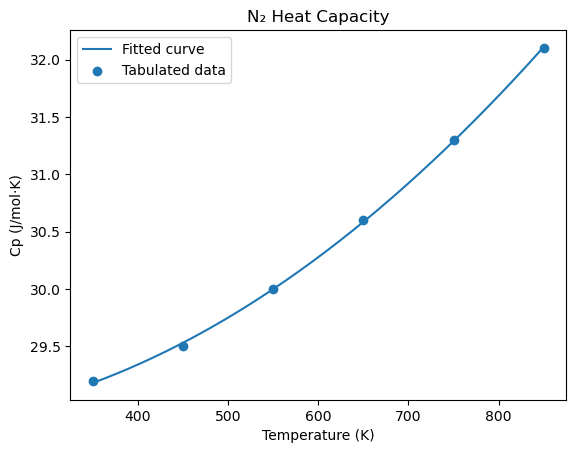

In [16]:
# Task 3 — plot tabulated data and fitted curve
from matplotlib import pyplot as plt
T_smooth = np.linspace(350, 850, 300)
plt.plot(T_smooth, Cp_fit(T_smooth), label="Fitted curve")
plt.scatter(T_data, Cp_data, label="Tabulated data")

plt.xlabel("Temperature (K)")
plt.ylabel("Cp (J/mol·K)")
plt.title("N₂ Heat Capacity")
plt.legend()
plt.show()

---

### B3 (35 pts; ⏱ ~15 min)

A heat exchanger cools a reactor effluent stream. The outlet temperature is modeled as:

$$T_{out} = T_{in} - \frac{Q}{\dot{m} \, c_p}$$

where:
- $T_{in} = 130\,°C$ (fixed inlet temperature)
- $Q = 10{,}000\,\text{W}$ (fixed heat removed)
- $c_p = 4.20\,\text{J g}^{-1}\,°C^{-1}$ (fixed heat capacity of the fluid)
- $\dot{m} \sim \mathcal{N}(90,\;5^2)\,\text{g/s}$ (mass flow rate, **normally distributed**)

The outlet temperature must be **no more than 100 °C** to meet process safety requirements.

**(Task 1 — 5 pts):** Compute $T_{out}$ at the mean flow rate $\dot{m} = 90\,\text{g/s}$. Check whether it meets the spec.

**(Task 2 — 17 pts):** Generate $N = 50{,}000$ samples of $\dot{m}$ and compute $T_{out}$ for each. Then find:
- Mean and standard deviation of $T_{out}$
- Fraction of runs where $T_{out} > 100\,°C$ (failure rate)

**(Task 3 — 13 pts):** If the standard deviation of $\dot{m}$ is reduced from 5 g/s to 2 g/s (e.g., by installing a better flow controller), would you expect the failure rate to increase, decrease, or stay the same? Explain your reasoning in 1–2 sentences. You may also write and use code to evaluate this effect quantitatively.

In [7]:
import numpy as np

T_in   = 130.0   # °C
Q      = 10000.0 # W
cp     = 4.20    # J/(g·°C)
spec_T = 100.0   # °C  (must be ≤ this)

# Task 1 — nominal outlet temperature at mean flow rate
mdot_mean = 90.0   # g/s
T_nominal = T_in - Q / (mdot_mean * cp)
print(f"T_nominal = {T_nominal:.2f} °C")

# Check whether T_nominal meets the spec
if T_nominal <= spec_T:
    print("Yes, it meets the spec.")
else:
    print("No, it does not meet the spec.")

T_nominal = 103.54 °C
No, it does not meet the spec.


In [8]:
# Task 2 — Monte Carlo
N   = 50_000
rng = np.random.default_rng(seed=42)

# Sample mdot from normal distribution with mean=90, std=5
mdot_samples = rng.normal(loc=90, scale=5, size=N)

# Do Monte Carlo to compute T_out for each sample
T_out_samples = T_in - Q / (mdot_samples * cp)

# Compute mean, std, and failure rate
mean_T    = np.mean(T_out_samples)
std_T     = np.std(T_out_samples)
fail_rate = np.sum(T_out_samples > spec_T) / N

print(f"\nMonte Carlo results (N = {N:,}):")
print(f"  Mean T_out   = {mean_T:.2f} °C")
print(f"  Std T_out    = {std_T:.2f} °C")
print(f"  Failure rate = {fail_rate*100:.2f}%")


Monte Carlo results (N = 50,000):
  Mean T_out   = 103.46 °C
  Std T_out    = 1.49 °C
  Failure rate = 98.29%


**(Task 3)** Reducing the standard deviation of $\dot{m}$ from 5 g/s to 2 g/s would **increase** the failure rate. Because the nominal outlet temperature (~103.5 °C) is already **above** the 100 °C spec, a wider spread (std = 5) allows more high-flow samples to cool the stream below 100 °C, reducing failures. Tightening the distribution (std = 2) concentrates samples near the already-failing mean, so fewer runs fall below the spec limit. The code below confirms this quantitatively.

In [9]:
# Task 3 - Feel free to write your code for the comparison
mdot_tight    = rng.normal(loc=90, scale=2, size=N)
T_out_tight   = T_in - Q / (mdot_tight * cp)
fail_rate_tight = np.sum(T_out_tight > spec_T) / N

print(f"Failure rate (std=5 g/s): {fail_rate*100:.2f}%")
print(f"Failure rate (std=2 g/s): {fail_rate_tight*100:.2f}%")

Failure rate (std=5 g/s): 98.29%
Failure rate (std=2 g/s): 100.00%
